In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Les incontournables
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

# scikit-learn est découpé en (nombreux) sous-modules: on importe au fur et à mesure des besoins
from sklearn import datasets

# reproductibilité: on fixe la graine du générateur pseudo-aléatoire
np.random.seed(42)

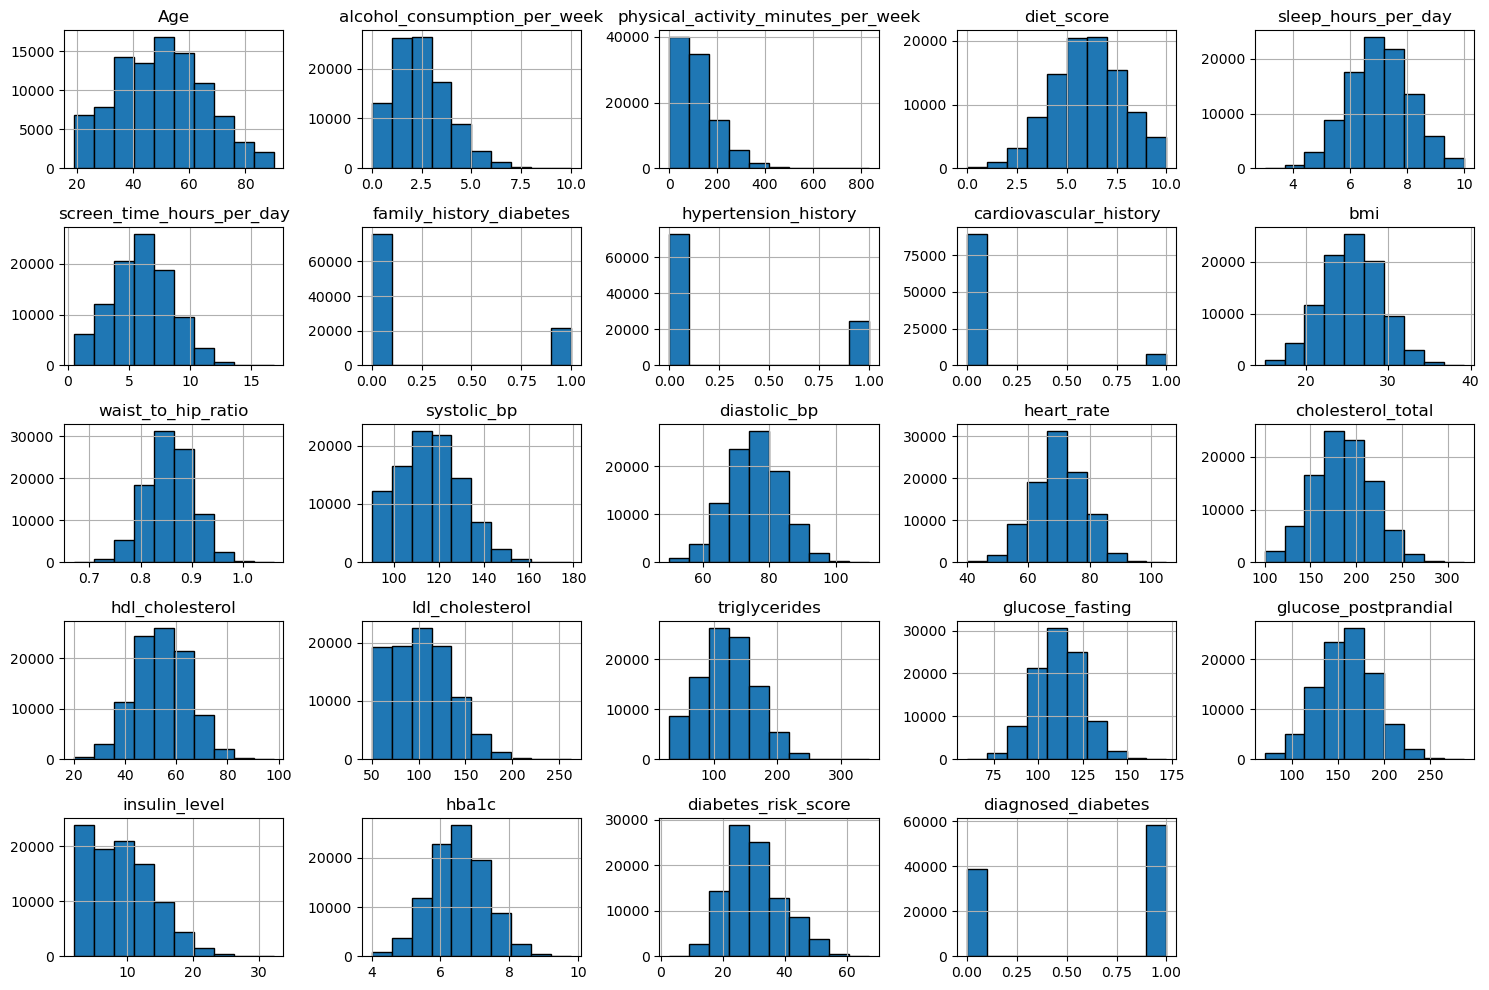

In [5]:
df = pd.read_csv('data/Diabetes_and_LifeStyle_Dataset.csv', encoding='utf-8')

df.hist(edgecolor="black", figsize=(15, 10))
plt.tight_layout()
plt.show()


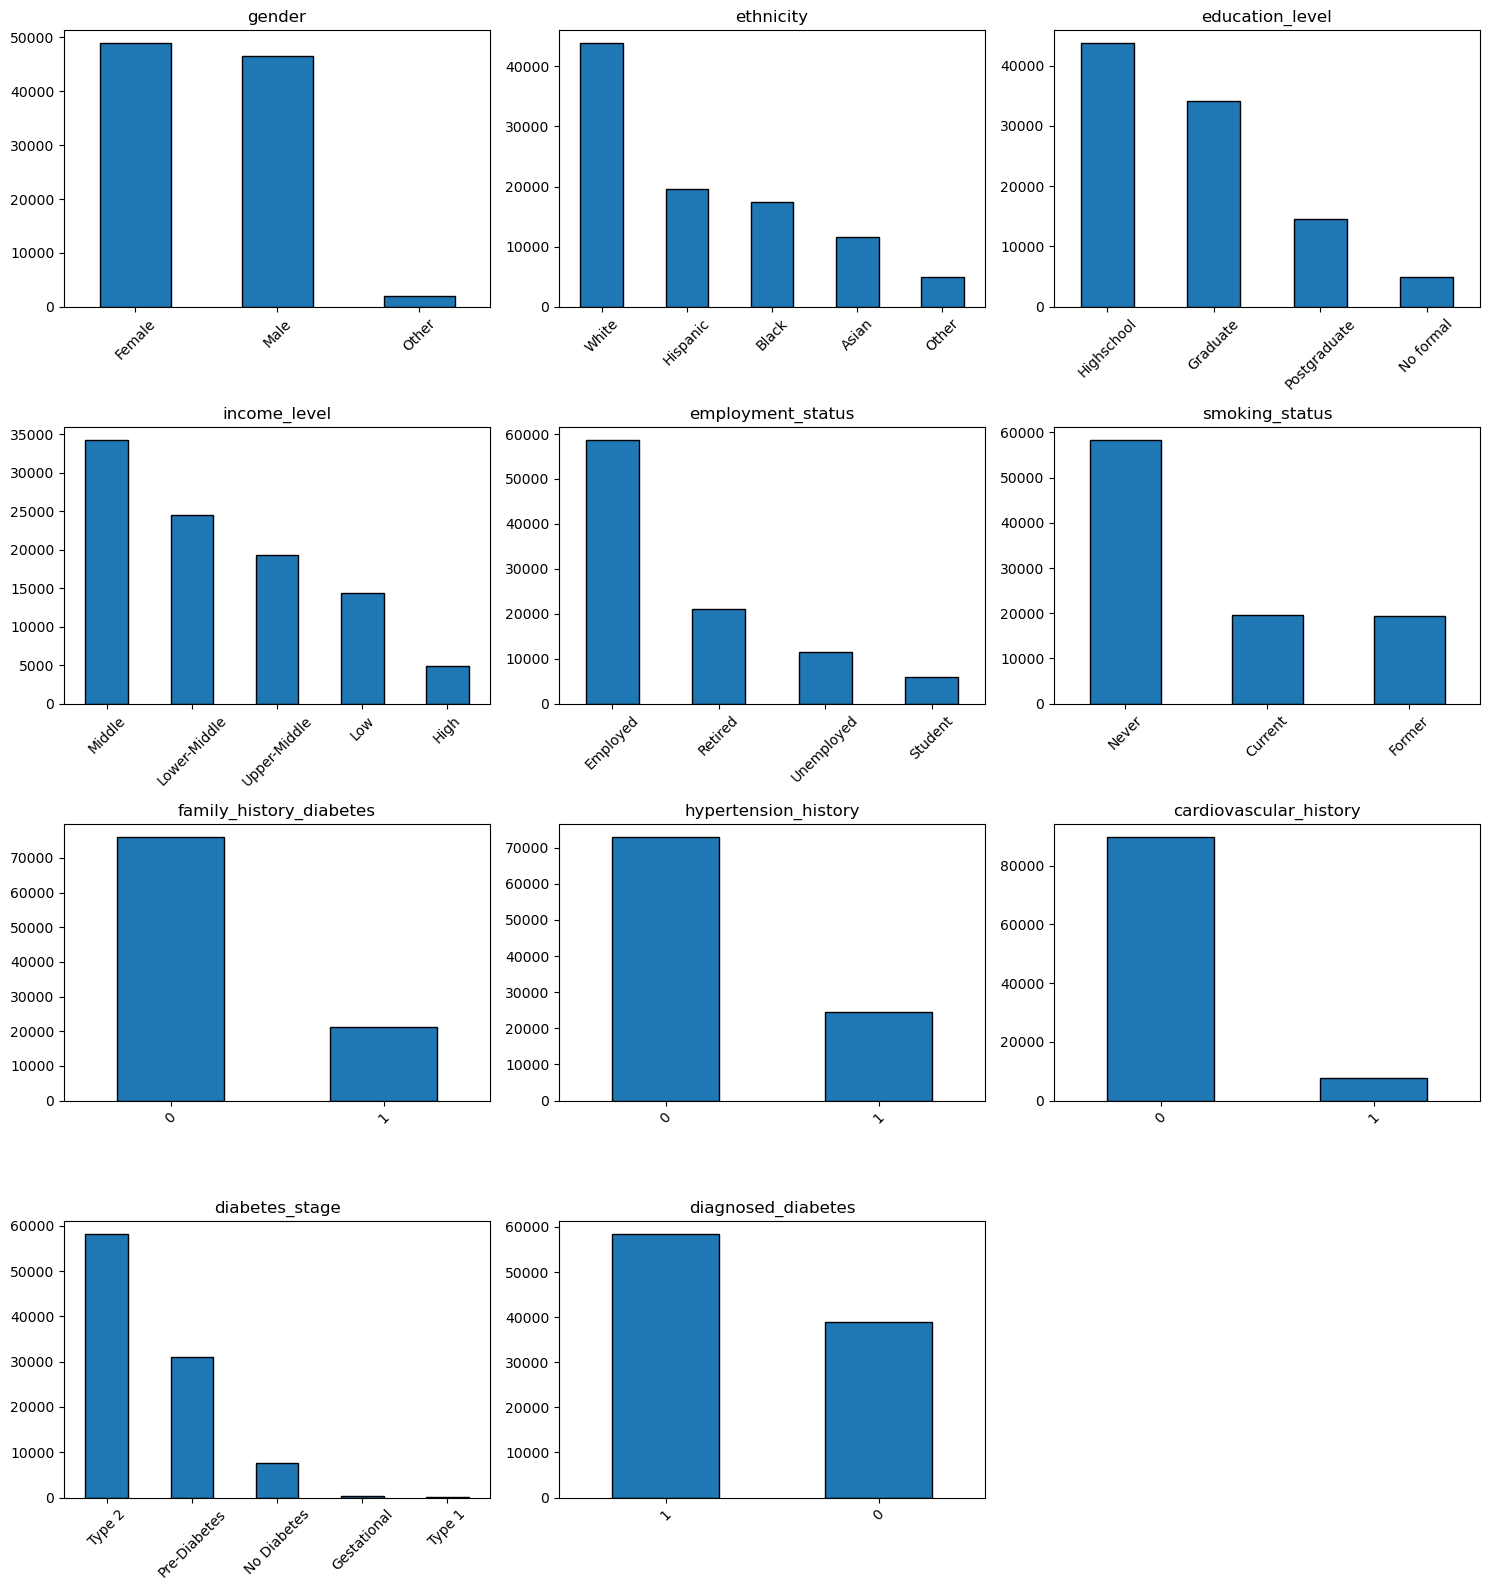

In [6]:
import math

# Colonnes catégorielles : texte, ou numériques avec peu de valeurs distinctes (ex. 0/1)
cat_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() <= 10]

ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)  # masque les cases vides de la grille

plt.tight_layout()
plt.show()

In [7]:
valeurs_manquantes = df.isna().sum().sum()
print("Nombre de valeurs manquantes dans le jeu de données :", valeurs_manquantes)

Nombre de valeurs manquantes dans le jeu de données : 0


                                         Age  alcohol_consumption_per_week  \
Age                                 1.000000                      0.000774   
alcohol_consumption_per_week        0.000774                      1.000000   
physical_activity_minutes_per_week  0.003020                     -0.002082   
diet_score                         -0.003175                     -0.000311   
sleep_hours_per_day                -0.003505                      0.001837   
screen_time_hours_per_day          -0.006167                      0.001794   
family_history_diabetes            -0.002675                      0.003062   
hypertension_history                0.177312                     -0.007438   
cardiovascular_history              0.147476                     -0.005129   
bmi                                 0.093728                     -0.002852   
waist_to_hip_ratio                  0.070225                     -0.003895   
systolic_bp                         0.547095                    

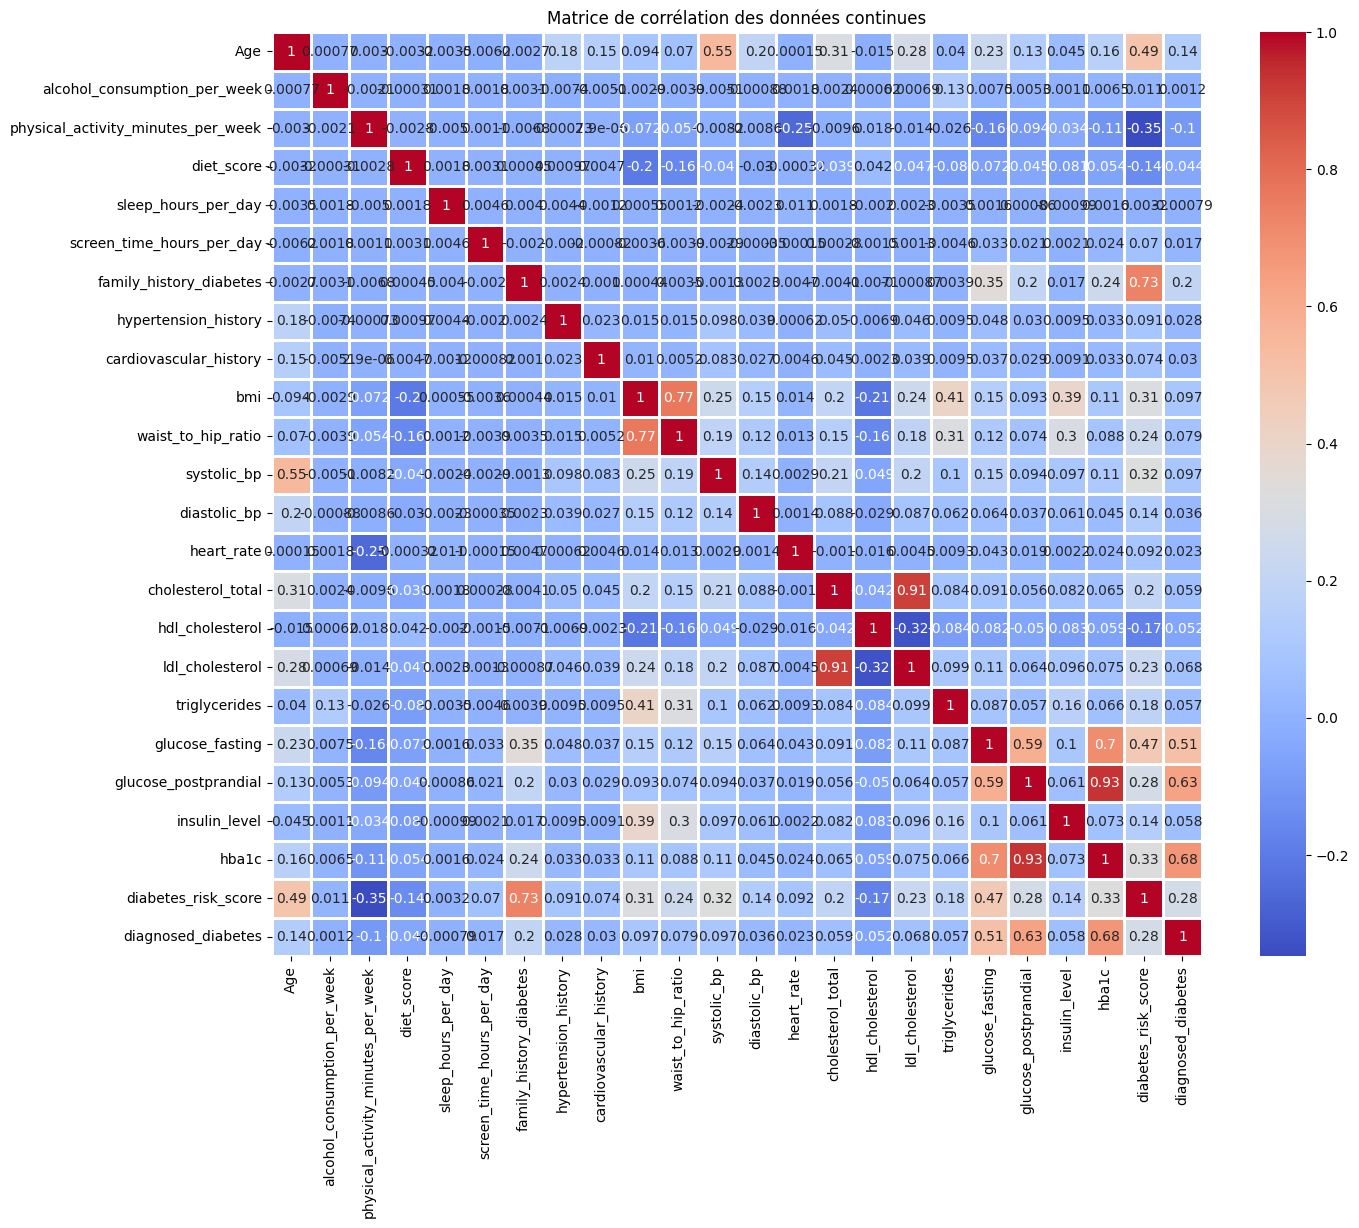

In [29]:
#Matrice de correlation
import seaborn 
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(15, 12))
seaborn.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidth=2)
plt.title("Matrice de corrélation des données continues")
plt.show()

In [54]:
## Transformation des données catégorielles en variables numériques
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

categorical_cols = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

numeric_cols = X.select_dtypes(include="number").columns.tolist()

# print(df.columns.tolist())

target_cols = [
    "diabetes_risk_score",
    "diagnosed_diabetes",
    "diabetes_stage",
]

X = df.drop(columns=target_cols)

y_risk = df["diabetes_risk_score"]
y_diagnosed = df["diagnosed_diabetes"]
y_stage = df["diabetes_stage"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numeric", StandardScaler(), numeric_cols),
    ],
    remainder="passthrough",  # conserve les colonnes numériques
    verbose_feature_names_out=False,
)

In [55]:
X_enc = preprocessor.fit_transform(X)

# Les noms générés, par exemple categorical__gender_Female
feature_names = preprocessor.get_feature_names_out()

# Convertit le résultat en tableau dense si sklearn l'a renvoyé en format creux
if hasattr(X_enc, "toarray"):
    X_enc = X_enc.toarray()

X_enc_df = pd.DataFrame(
    X_enc,
    columns=feature_names,
    index=X.index,
)

display(X_enc_df.head())
display(y_risk.head())
display(y_diagnosed.head())
display(y_stage.head())
# les y pas convertis c'est ok

,gender_Female,gender_Male,gender_Other,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Graduate,education_level_Highschool,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.337054,-0.194515,1.656058,-1.269445,1.707090,0.542334,1.830584,2.456002,-0.545484,2.039633
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.093345,-0.313937,-2.186103,0.093086,-1.587312,-2.107851,-1.333435,-0.323683,-1.425170,-1.094176
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.272219,0.522015,0.843894,1.163647,-0.119806,-1.969581,0.506111,1.130803,-0.805758,1.216240
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,2.164871,-0.194515,-0.468064,-0.393532,-0.718788,0.427108,2.051330,3.005475,-0.763388,3.084237
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-1.003346,-0.313937,0.750183,-0.198884,0.658871,0.888010,1.904166,0.775262,0.741762,0.835267


0    29.6
1    23.0
2    44.7
3    38.2
4    23.5
Name: diabetes_risk_score, dtype: float64

0    1
1    0
2    1
3    1
4    1
Name: diagnosed_diabetes, dtype: int64

0         Type 2
1    No Diabetes
2         Type 2
3         Type 2
4         Type 2
Name: diabetes_stage, dtype: object

## Premier modèle sur le diagnostic du diabètes

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Découpe Y en 10 groupes de même taille, du score le plus bas au plus haut
# Y_bins = pd.qcut(y_diagnosed, q=10, labels=False, duplicates='drop')
X_train, X_test, Y_train, Y_test = train_test_split(
    X_enc_df, y_diagnosed,
    test_size=0.2,       # 20 % des données en test
    random_state=42,     # même découpage à chaque exécution
    stratify=y_diagnosed
)

# Vérification de la répartition des classes dans les ensembles train et test
print("Ensemble complet :")
print(y_diagnosed.value_counts(normalize=True))

print("Train :")
print(Y_train.value_counts(normalize=True))

print("Test :")
print(Y_test.value_counts(normalize=True))


Ensemble complet :
1    0.600039
0    0.399961
Name: diagnosed_diabetes, dtype: float64
Train :
1    0.600036
0    0.399964
Name: diagnosed_diabetes, dtype: float64
Test :
1    0.600051
0    0.399949
Name: diagnosed_diabetes, dtype: float64


'mod = LinearRegression()\nmod.fit(X_train, Y_train)\ny_hat = mod.predict(X_test)\n\n# Évaluation du modèle\nmae = mean_absolute_error(Y_test, y_hat)\nrmse = np.sqrt(mean_squared_error(Y_test, y_hat))\nr2 = r2_score(Y_test, y_hat)\n\nprint(f"MAE  : {mae:.2f}")\nprint(f"RMSE : {rmse:.2f}")\nprint(f"R²   : {r2:.3f}")'

#### Modèle SVM

In [ ]:
# Initialisation du modèle
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Pas de preprocessor car données déjà standardisées et passées au OneHotEncoder
pipeline_SVM = Pipeline(steps=[('classifier', SVC(kernel='rbf'))])
pipeline_SVM.fit(X_train, Y_train)

score = pipeline_SVM.score(X_test, Y_test)
print(f"Score du modèle (accuracy) : {score:.2f}")

Score du modèle : 0.84


#### Modèle KNN
####### fixer le marapètre n_neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as met
mod_knn=KNeighborsClassifier(n_neighbors=3)
mod_knn.fit(X_train, Y_train)
y_hat=mod_knn.predict(X_test)
acc=met.accuracy_score(Y_test,y_hat) #accuracy
print("Accuracy du modèle :", acc)

0.7975334018499486


#### Modèle Décision Tree

In [ ]:
from sklearn import tree
import sklearn.metrics as met
mod_tree=tree.DecisionTreeClassifier()
mod_tree.fit(X_train, Y_train)
y_hat=mod_tree.predict(X_test)
acc=met.accuracy_score(Y_test,y_hat)
print("Accuracy du modèle :", acc)

0.8607399794450155


## Modèle sur y_stage

In [32]:
X_train_stage, X_test_stage, Y_train_stage, Y_test_stage = train_test_split(
    X_enc_df, y_stage,
    test_size=0.2,       # 20 % des données en test
    random_state=42,     # même découpage à chaque exécution
    stratify=y_stage
)

# Vérification de la répartition des classes dans les ensembles train et test
print("Ensemble complet :")
print(y_stage.value_counts(normalize=True))

print("Train :")
print(Y_train_stage.value_counts(normalize=True))

print("Test :")
print(Y_test_stage.value_counts(normalize=True))

Ensemble complet :
Type 2          0.597788
Pre-Diabetes    0.318746
No Diabetes     0.079519
Gestational     0.002744
Type 1          0.001203
Name: diabetes_stage, dtype: float64
Train :
Type 2          0.597788
Pre-Diabetes    0.318743
No Diabetes     0.079512
Gestational     0.002749
Type 1          0.001208
Name: diabetes_stage, dtype: float64
Test :
Type 2          0.597790
Pre-Diabetes    0.318756
No Diabetes     0.079548
Gestational     0.002724
Type 1          0.001182
Name: diabetes_stage, dtype: float64


In [33]:
# Modèle KNN
mod_knn=KNeighborsClassifier(n_neighbors=3)
mod_knn.fit(X_train_stage, Y_train_stage)
y_hat=mod_knn.predict(X_test_stage)
acc=met.accuracy_score(Y_test_stage,y_hat) #accuracy
print("Accuracy du modèle :", acc)

Accuracy du modèle : 0.731294964028777


In [34]:
from sklearn import tree
import sklearn.metrics as met
mod_tree=tree.DecisionTreeClassifier()
mod_tree.fit(X_train_stage, Y_train_stage)
y_hat=mod_tree.predict(X_test_stage)
acc=met.accuracy_score(Y_test_stage,y_hat)
print("Accuracy du modèle :", acc)

Accuracy du modèle : 0.8550359712230216


## risk : regretion

In [48]:
# Découpe Y en 10 groupes de même taille, du score le plus bas au plus haut
Y_bins = pd.qcut(y_risk, q=10, labels=False, duplicates='drop')

X_train_risk, X_test_risk, Y_train_risk, Y_test_risk = train_test_split(
    X_enc_df, y_risk,
    test_size=0.2,       # 20 % des données en test
    random_state=42,     # même découpage à chaque exécution
    stratify=Y_bins  #regarder si pas chelou de cut en 10 classes les données et pour qu'elles soient répartis de manière homogène entre train et test
)

# Vérification de la répartition des classes dans les ensembles train et test
print("Ensemble complet :")
print(y_risk.value_counts(normalize=True))

print("Train :")
print(Y_train_risk.value_counts(normalize=True))

print("Test :")
print(Y_test_risk.value_counts(normalize=True))

Ensemble complet :
27.8    0.005519
26.6    0.005488
26.7    0.005344
27.2    0.005314
26.5    0.005303
          ...   
64.1    0.000010
67.2    0.000010
4.6     0.000010
61.1    0.000010
62.9    0.000010
Name: diabetes_risk_score, Length: 569, dtype: float64
Train :
27.8    0.005499
26.6    0.005447
26.7    0.005370
26.5    0.005332
26.8    0.005306
          ...   
61.1    0.000013
61.8    0.000013
59.3    0.000013
60.8    0.000013
61.3    0.000013
Name: diabetes_risk_score, Length: 562, dtype: float64
Test :
26.3    0.006372
28.2    0.005910
29.2    0.005858
26.6    0.005653
27.8    0.005601
          ...   
5.5     0.000051
7.2     0.000051
7.9     0.000051
7.7     0.000051
58.9    0.000051
Name: diabetes_risk_score, Length: 511, dtype: float64


In [ ]:
#KNN reg
from sklearn.neighbors import KNeighborsRegressor
mod_knn=KNeighborsRegressor(n_neighbors=3) #n_n à ajuster avec cv ?
mod_knn.fit(X_train_risk, Y_train_risk)
y_hat=mod_knn.predict(X_test_risk)
mae = met.mean_absolute_error(Y_test_risk, y_hat)
rmse=met.root_mean_squared_error(Y_test_risk,y_hat)
r2 = met.r2_score(Y_test_risk, y_hat)
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 2.3916786570743405
RMSE : 3.0373288346337124
R2 : 0.8877122884597894


In [ ]:
#regression linéaire

mod_linear = LinearRegression()
mod_linear.fit(X_train_risk, Y_train_risk)
y_hat = mod_linear.predict(X_test_risk)

# Évaluation du modèle
mae = met.mean_absolute_error(Y_test_risk, y_hat)
rmse = met.root_mean_squared_error(Y_test_risk, y_hat)
r2 = met.r2_score(Y_test_risk, y_hat)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 0.4892406130330067
RMSE : 0.7866356176412109
R2 : 0.9924682513539119
